In [1]:
import pandas as pd
import geopandas as geopandas
import hkvsobekpy
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# selectie_gebied = 0 # Oude IJssel
# selectie_gebied = 1 # West
# selectie_gebied = 2 # Centraal
# selectie_gebied = 3 # Oost

selectie_gebieden = [2]

scenarios = ["REF", "SCEN"]
# scenarios = ["REF"]

start_date = "2010-4-1"
end_date = "2018-12-31"
# end_date = "2010-4-12"

# path to the package containing the dummy-data
dir_model_basis = "..\\..\\WRIJ_RR_Unpaved_methode_03_modellen\\oude_ijssel\\"

In [4]:
simulaties_total = pd.DataFrame()

for selectie_gebied in selectie_gebieden:
    for scenario in scenarios:
        date_range = pd.date_range(start_date, end_date, freq="6MS")
        # date_range = pd.date_range(start_date, end_date, freq="2D")

        simulaties = pd.DataFrame()
        simulaties["start_date"] = date_range
        simulaties["end_date"] = simulaties["start_date"].shift(-1)
        simulaties.loc[simulaties.index[-1],"end_date"] = pd.to_datetime(end_date)
        simulaties["seizoen"] = ["zomer", "winter"]*int(len(date_range)/2)
        simulaties["scenario"] = scenario
        simulaties["gebied"] = selectie_gebied
        simulaties["restart_in"] = [0] + [1] * len(simulaties.index[1:])

        simulaties["model_name"] = simulaties.apply(lambda x: f"rr_model__{pd.to_datetime(x.start_date).strftime('%Y_%m_%d')}__{pd.to_datetime(x.end_date).strftime('%Y_%m_%d')}", axis=1)
        simulaties_total = pd.concat([simulaties_total, simulaties])

In [5]:
total_link_flows = pd.DataFrame()

for selectie_gebied in selectie_gebieden:
    for scenario in scenarios:
        simulaties = simulaties_total[(simulaties_total["gebied"]==selectie_gebied) & (simulaties_total["scenario"]==scenario)]
        link_flows = pd.DataFrame()
        for index, simulatie in simulaties.iterrows():
            print(str(simulatie.gebied) + " - " + simulatie.scenario + " - " + simulatie.model_name)

            dir_model = Path(dir_model_basis, f"gebied_{simulatie.gebied}", simulatie.scenario)
            unpaved_rr_file = "3blinks.his"

            path_unpaved_rr_file = Path(dir_model, simulatie.model_name, "rr", unpaved_rr_file)
            if not path_unpaved_rr_file.exists():
                print(f"File {path_unpaved_rr_file} does not exist. Skipping.")
                continue
            rr_his = hkvsobekpy.read_his.ReadMetadata(path_unpaved_rr_file)
            rr_results_link_flow = rr_his.DataFrame()['Link flow [m3/s]    ']
            link_flows = pd.concat([link_flows, rr_results_link_flow])
        
        total_link_flows[f"{selectie_gebied}_{scenario}"] = link_flows.sum(axis=1)        

2 - REF - rr_model__2010_04_01__2010_10_01
2 - REF - rr_model__2010_10_01__2011_04_01
2 - REF - rr_model__2011_04_01__2011_10_01
2 - REF - rr_model__2011_10_01__2012_04_01
2 - REF - rr_model__2012_04_01__2012_10_01
2 - REF - rr_model__2012_10_01__2013_04_01
2 - REF - rr_model__2013_04_01__2013_10_01
2 - REF - rr_model__2013_10_01__2014_04_01
2 - REF - rr_model__2014_04_01__2014_10_01
2 - REF - rr_model__2014_10_01__2015_04_01
2 - REF - rr_model__2015_04_01__2015_10_01
2 - REF - rr_model__2015_10_01__2016_04_01
2 - REF - rr_model__2016_04_01__2016_10_01
2 - REF - rr_model__2016_10_01__2017_04_01
2 - REF - rr_model__2017_04_01__2017_10_01
2 - REF - rr_model__2017_10_01__2018_04_01
2 - REF - rr_model__2018_04_01__2018_10_01
2 - REF - rr_model__2018_10_01__2018_12_31
2 - SCEN - rr_model__2010_04_01__2010_10_01
2 - SCEN - rr_model__2010_10_01__2011_04_01
2 - SCEN - rr_model__2011_04_01__2011_10_01
2 - SCEN - rr_model__2011_10_01__2012_04_01
2 - SCEN - rr_model__2012_04_01__2012_10_01
2 - SC

In [6]:
total_link_flows

,2_REF,2_SCEN
2010-04-01 00:00:00,0.000000,0.000000
2010-04-01 00:05:00,0.000379,0.000384
2010-04-01 00:10:00,0.003494,0.015831
2010-04-01 00:15:00,0.003487,0.015639
2010-04-01 00:20:00,0.003492,0.015461
...,...,...
2018-12-30 23:40:00,0.126506,0.021268
2018-12-30 23:45:00,0.126471,0.021264
2018-12-30 23:50:00,0.126435,0.021261
2018-12-30 23:55:00,0.126400,0.021257


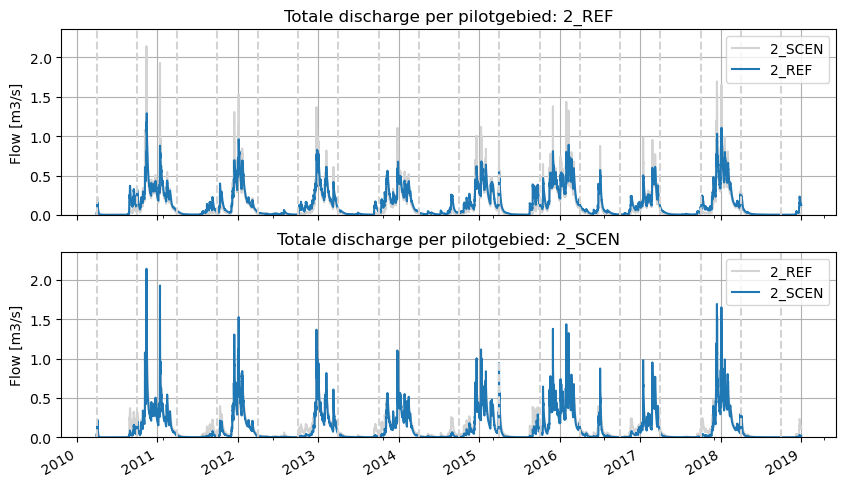

In [15]:
fig, axs = plt.subplots(len(total_link_flows.columns), 1, figsize=(10,6), sharex=True)
for i, col in enumerate(total_link_flows.columns):
    total_link_flows.drop(columns=[col]).plot(ax=axs[i], color='lightgrey')
    total_link_flows[[col]].plot(ax=axs[i])
    ymin = 0
    ymax = total_link_flows.max().max()*1.1
    axs[i].vlines(simulaties.start_date, ymin=ymin, ymax=ymax, color="lightgrey", linestyles="dashed")
    axs[i].set_ylim([ymin, ymax]);

    # Titel en y-as label toevoegen
    axs[i].set_title(f"Totale discharge per pilotgebied: {col}")
    axs[i].set_ylabel("Flow [m3/s]")
    axs[i].grid()


Text(0, 0.5, 'Flow [m3/s]')

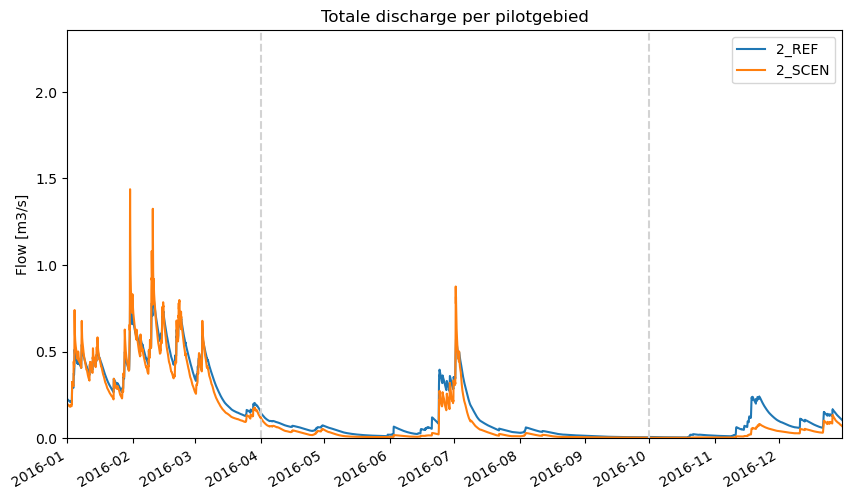

In [8]:
#Inzoomen
fig, ax = plt.subplots(1, 1, figsize=(10,6))

total_link_flows.plot(ax=ax)

ymin = 0
ymax = total_link_flows.max().max()*1.1

ax.vlines(simulaties.start_date, ymin=ymin, ymax=ymax,
          color="lightgrey", linestyles="dashed")

ax.set_ylim([ymin, ymax])

# Inzoomen op 2016
ax.set_xlim(["2016-01-01", "2016-12-31"])

ax.set_title("Totale discharge per pilotgebied")
ax.set_ylabel("Flow [m3/s]")